# Network Analysis -- Assignment 01
## A Network of Thrones: Characterising the Game of Thrones Character Network

**Course:** Network Analysis 2025/26  \
**Submission Date:** Via Moodle, 27/03/2025 \
**Group size:** 4 students  
**Group:** B \
Member 1: Beatriz Soares Marques -- 20231605 \
Member 2: Maria Inês Lopes dos Santos -- 20231630 \
Member 3: Luís Rafael da Costa Soeiro -- 20211536 \
Member 4: Rodrigo Teixeira da Silva -- 20231602

**Submission instructions** 
Rename this file to include your group identifier before submitting. The file name should follow the format Assignment01_GroupX.ipynb, where X is replaced by your group letter or number (for example, Assignment01_GroupA.ipynb).
Inside the notebook, fill in the cell below with the names and student numbers of all three group members before beginning the assignment. Submissions missing this information will not be graded.

### Overview

In this assignment you will analyse a real-world network derived from George R.R. Martin's *A Song of Ice and Fire*, the book series on which Game of Thrones is based. Two characters are linked if their names appear within 15 words of each other in the text of Book 1. The weight of each edge reflects how frequently this co-occurrence takes place.

Your task is to characterise this network using the metrics and methods covered in lectures and labs, and to draw meaningful conclusions about the social structure of the story from the results.

**Dataset:** Network of Thrones (Beveridge and Shan, 2016)  
**Source:** https://raw.githubusercontent.com/mathbeveridge/asoiaf/master/data/asoiaf-book1-edges.csv

---

### Grading criteria

| Points | Description |
|--------|-------------|
| 0      | Not delivered |
| 10     | Delivered but incomplete |
| 15     | Complete but not all expected outputs achieved |
| 20     | Complete and all expected outputs achieved |

---

## Part 0 -- Setup

Run the cell below before starting.

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go


%matplotlib inline
print(f"NetworkX version: {nx.__version__}")
print("Ready.")

NetworkX version: 3.6.1
Ready.


---

## Part 1 -- Load and Build the Network

### 1.1 -- Load the dataset

Load the edge list from the URL above into a Pandas DataFrame and display the first few rows.

In [2]:
df = pd.read_csv('book_edges.csv')
df.head(10)

,Source,Target,Type,weight,book
0,Addam-Marbrand,Jaime-Lannister,Undirected,3,1
1,Addam-Marbrand,Tywin-Lannister,Undirected,6,1
2,Aegon-I-Targaryen,Daenerys-Targaryen,Undirected,5,1
3,Aegon-I-Targaryen,Eddard-Stark,Undirected,4,1
4,Aemon-Targaryen-(Maester-Aemon),Alliser-Thorne,Undirected,4,1
5,Aemon-Targaryen-(Maester-Aemon),Bowen-Marsh,Undirected,4,1
6,Aemon-Targaryen-(Maester-Aemon),Chett,Undirected,9,1
7,Aemon-Targaryen-(Maester-Aemon),Clydas,Undirected,5,1
8,Aemon-Targaryen-(Maester-Aemon),Jeor-Mormont,Undirected,13,1
9,Aemon-Targaryen-(Maester-Aemon),Jon-Snow,Undirected,34,1


### 1.2 -- Build the graph

Construct a NetworkX graph from the DataFrame. Ensure that the edge weight attribute is included.

Hint: use `nx.from_pandas_edgelist()` and inspect the column names in your DataFrame beforehand.

In [3]:
print(list(df.columns))

G = nx.from_pandas_edgelist(
    df,
    source="Source",
    target="Target",
    edge_attr="weight",   
    create_using=nx.Graph() # undirected
    )

['Source', 'Target', 'Type', 'weight', 'book']


### 1.3 -- Basic properties

Report the following:
- Number of nodes (N)
- Number of edges (L)
- Whether the graph is directed or undirected
- Whether the graph is weighted

In [4]:
# Number of nodes (N)
N = G.number_of_nodes()

# Number of edges (L)
L = G.number_of_edges()

# Directed or undirected
is_directed = G.is_directed()

# Weighted
is_weighted = nx.is_weighted(G)

print("Number of nodes (N):", N)
print("Number of edges (L):", L)
print("Directed:", is_directed)
print("Weighted:", is_weighted)

Number of nodes (N): 187
Number of edges (L): 684
Directed: False
Weighted: True


### 1.4 -- Visualise the network

Produce a plot of the network. Use node size or colour to encode a meaningful property such as degree. The network is large, so full readability of labels is not expected.

In [5]:
# layout
pos = nx.spring_layout(G, k=0.3, iterations=20, seed=42) # k changes distance between nodes

# Node degree
degrees = dict(G.degree())

# sizes and colours
node_sizes = [5 + degrees[node]*2 for node in G.nodes()] # if we want to see degree diferenciation using node size
node_colors = [degrees[node] for node in G.nodes()] # if we want to see degree diferenciation using color scale

# edge traces
edge_x = []
edge_y = []

for u, v in G.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    line=dict(width=0.5),
    hoverinfo='none',
    mode='lines'
)

# node traces
node_x = []
node_y = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='markers',
    hoverinfo='text',
    marker=dict(
        size=18, # use node_sizes here
        color=node_colors,
        colorscale='Inferno',
        showscale=True,
        colorbar=dict(title='Degree'),
        line_width=0.5
    )
)

# hover text + figure
node_text = [f"{node}<br>Degree: {degrees[node]}" for node in G.nodes()]
node_trace.text = node_text
fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(
                title=dict(
                    text="Game of Thrones character network graph",
                    x=0.5,       
                    xanchor='center',
                    yanchor='top',
                    font=dict(
                        family="Tahoma",
                        size=22,
                        color="black"
                    )),
                showlegend=False,
                hovermode='closest',
                margin=dict(b=20,l=5,r=5,t=40),
                width=1400,
                height=800,
                xaxis=dict(showgrid=False, zeroline=False, visible=False),
                yaxis=dict(showgrid=False, zeroline=False, visible=False)
                ))

fig.show()

---

## Part 2 -- Degree Distribution

### 2.1 -- Compute degree

Compute the degree of every node. Report the 10 highest-degree characters.

In [1]:
# degree sorted
top_10 = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]

# 10 highest degrees
print("Top 10 highest-degree characters:")
top_10_df = pd.DataFrame(top_10, columns=["Character", "Degree"])
top_10_df

NameError: name 'degrees' is not defined

### 2.2 -- Plot the degree distribution

Plot the degree distribution. Include clearly labelled axes and a title. Consider whether a log-log representation reveals additional structure.

In [ ]:
# degree frequency
degrees = [d for n, d in G.degree()]
degree_counts = {}
for d in degrees:
    degree_counts[d] = degree_counts.get(d, 0) + 1

# degree sorted
deg, cnt = zip(*sorted(degree_counts.items()))

In [ ]:
# FIXME
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=deg,
    y=cnt,
    mode='lines+markers',
    marker=dict(
        color='purple',
        size=8,
        line=dict(width=1, color='black')
    )
))

fig.update_layout(
    title=dict(
        text="Degree Distribution of Game of Thrones Network",
        x=0.5,       
        xanchor='center',
        yanchor='top',
        font=dict(
            family="Tahoma",
            size=21,
            color="black"
        )),
    xaxis_title="Degree",
    yaxis_title="Number of Nodes",
    template="plotly_white",
)

fig.show()

In [ ]:
# FIXME
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=deg,
    y=cnt,
    mode='lines+markers',
    marker=dict(
        color='purple',
        size=8,
        line=dict(width=1, color='black')
    )
))

fig.update_layout(
    title=dict(
        text="Degree Distribution of Game of Thrones Network (Log-Log)",
        x=0.5,       
        xanchor='center',
        yanchor='top',
        font=dict(
            family="Tahoma",
            size=21,
            color="black"
        )),
    xaxis_title="Degree",
    yaxis_title="Number of Nodes",
    xaxis_type="log",
    yaxis_type="log",
    template="plotly_white"
)

fig.show()

In [ ]:
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print('Average degree:', avg_degree)

Average degree: 7.315508021390374


### 2.3 -- Discussion

1. What is the average degree of the network?
2. What is the shape of the degree distribution and what does it indicate about the network?
3. Do the highest-degree characters reflect their narrative importance in Book 1?

> **1.** On average, each character is connected to about 7 other characters, as the average degree of the network is approximately 7.32.

> **2.** The degree distribution is right-skewed, indicating the presence of a few highly connected characters (hubs) that dominate interactions. Its approximately power-law-like shape suggests the network may exhibit scale-free behavior, meaning that node importance is unevenly distributed rather than equal across the network.

> **3.** Yes, the highest-degree characters reflect their narrative importance, as they interact with many others and connect different parts of the story, highlighting their central role in Book 1.

---

## Part 3 -- Clustering

### 3.1 -- Average clustering coefficient

Compute and report:

- The average clustering coefficient

In [13]:
avg_clustering = nx.average_clustering(G)
print("Average clustering coefficient:", avg_clustering)

Average clustering coefficient: 0.5121189412047715


### 3.2 -- Local clustering

Compute the local clustering coefficient for each node. Report the 10 characters with the highest values.

In [14]:
# local clustering coefficient
local_clustering = nx.clustering(G)

# top 10 characters with highest local clustering
top_10 = sorted(local_clustering.items(), key=lambda x: x[1], reverse=True)[:10]
df_top10 = pd.DataFrame(top_10, columns=['Character', 'Local Clustering Coefficient'])
df_top10

,Character,Local Clustering Coefficient
0,Addam-Marbrand,1.0
1,Aegon-I-Targaryen,1.0
2,Bowen-Marsh,1.0
3,Chett,1.0
4,Albett,1.0
5,Desmond,1.0
6,Mycah,1.0
7,Vayon-Poole,1.0
8,Balon-Greyjoy,1.0
9,Balon-Swann,1.0


### 3.3 -- Discussion

1. How would you interpret the clustering coefficient values obtained? What do they suggest about the social structure in Book 1?
2. Do the characters with the highest local clustering tend to belong to the same group or faction? What might explain this?


> **1.** On average, about half of a character’s neighbors are also connected to each other, indicating a moderate level of tightly connected communities. However, these communities are not uniform across the network, as some groups exhibit lower local cohesion. In practice, characters interact heterogeneously: some are connected within well-defined social circles, while others act as bridges between groups

> **2.** Yes, characters with the highest local clustering coefficients tend to belong to small, tightly knit groups. A clustering coefficient of 1.0 means that all of a character’s neighbors are fully connected, forming a clique. This typically occurs for minor or peripheral characters who appear in limited, highly localized contexts, rather than interacting broadly across the network.

---

## Part 4 -- Paths and Connectivity

### 4.1 -- Average path length and diameter

Compute the average shortest path length and the diameter of the network.

In [15]:
avg_path_length = nx.average_shortest_path_length(G)
diameter = nx.diameter(G)

print('Connected Graph:', nx.is_connected(G))
print("Average shortest path length:", avg_path_length)
print("Diameter:", diameter)

Connected Graph: True
Average shortest path length: 2.9124259674544306
Diameter: 7


### 4.2 -- Assortativity Mixing
Compute assortativity (r) and print r for the network.

In [16]:
r = nx.degree_assortativity_coefficient(G)
print("Assortativity (r):", r)

Assortativity (r): -0.1636399753256242


### 4.4 -- Discussion

1. Is the average path length short relative to the number of nodes? What does this imply about the network?
2. What does the assortativity r value tells us?

> **1.** Yes, the average shortest path length is relatively small compared to the size of the network. This indicates that most characters can be reached from one another through only a few steps, suggesting a highly connected network. The relatively small diameter of 7 further supports this, implying that even the most distant characters are not far apart.

> **2.** The assortativity coefficient indicates that the network is disassortative. This means that highly connected characters tend to interact with characters that have fewer connections, rather than with other highly connected characters.

---

## Part 5 -- Weighted Analysis

### 5.1 -- Node strength

Compute the strength of each node, defined as the sum of its edge weights. Report the 10 characters with the highest strength.

In [17]:
# Weights
weight = dict(G.degree(weight='weight'))

# top 10 nodes by weight
top_10_weight = sorted(weight.items(), key=lambda x: x[1], reverse=True)[:10]
df_weight = pd.DataFrame(top_10_weight, columns=['Character', 'Weight'])
df_weight

,Character,Weight
0,Eddard-Stark,1284
1,Robert-Baratheon,941
2,Jon-Snow,784
3,Tyrion-Lannister,650
4,Sansa-Stark,545
5,Bran-Stark,531
6,Catelyn-Stark,520
7,Robb-Stark,516
8,Daenerys-Targaryen,443
9,Arya-Stark,430


### 5.2 -- Degree versus strength

Construct a DataFrame containing the degree and strength of each character. Sort by strength and display the top 15 entries.

In [18]:
# Degree
degree_dict = dict(G.degree())
df_weight['Degree'] = df_weight['Character'].map(degree_dict)

# top 15 by weight
df_top15 = df_weight.sort_values(by='Weight', ascending=False).head(15)
df_top15

,Character,Weight,Degree
0,Eddard-Stark,1284,66
1,Robert-Baratheon,941,50
2,Jon-Snow,784,37
3,Tyrion-Lannister,650,46
4,Sansa-Stark,545,35
5,Bran-Stark,531,32
6,Catelyn-Stark,520,43
7,Robb-Stark,516,35
8,Daenerys-Targaryen,443,21
9,Arya-Stark,430,27


In [19]:
import plotly.graph_objects as go

# Scatter plot of Degree vs weight
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_weight['Degree'],           
    y=df_weight['Weight'],         
    mode='markers+text',
    text=df_weight['Character'],      
    textposition='top center',
    marker=dict(
        size=10,
        color='purple',
        line=dict(width=1, color='black')
    )
))

fig.update_layout(
    title="Character Degree vs Strength",
    xaxis_title="Degree (Number of Connections)",
    yaxis_title="Strength (Sum of Edge Weights)",
    template="plotly_white",
    width=900,
    height=600
)

fig.show()

### 5.3 -- Strongest edges

Report the 10 pairs of characters with the highest edge weight.

In [20]:
# edges with weights
edges = [(u, v, d['weight']) for u, v, d in G.edges(data=True)]

# top 10 edges by weight
top_10_edges = sorted(edges, key=lambda x: x[2], reverse=True)[:10]
df_top_edges = pd.DataFrame(top_10_edges, columns=['Character 1', 'Character 2', 'Weight'])
df_top_edges

,Character 1,Character 2,Weight
0,Eddard-Stark,Robert-Baratheon,291
1,Bran-Stark,Robb-Stark,112
2,Arya-Stark,Sansa-Stark,104
3,Daenerys-Targaryen,Drogo,101
4,Joffrey-Baratheon,Sansa-Stark,87
5,Eddard-Stark,Petyr-Baelish,81
6,Jeor-Mormont,Jon-Snow,81
7,Jon-Snow,Samwell-Tarly,81
8,Daenerys-Targaryen,Jorah-Mormont,75
9,Robert-Baratheon,Cersei-Lannister,72


### 5.4 -- Discussion

1. Do the degree and strength rankings agree? Where they diverge, what does this reveal about a character's interaction patterns?
2. Do the strongest character pairs correspond to meaningful relationships in Book 1?

> **1.** The degree and strength rankings largely agree, as the same main characters (Eddard Stark and Robert Baratheon for example) appear at the top of both lists. This indicates that the most connected characters also tend to have the most frequent interactions.
However, there are some differences in ordering, which reveal variations in interaction patterns. For example, a character like Tyrion Lannister has a relatively high degree but slightly lower strength compared to others, suggesting that he interacts with many different characters but not always very frequently with each. In contrast, characters such as Jon Snow may have fewer connections but higher strength relative to their degree, indicating more repeated or intense interactions within a smaller group.

> **2.** Yes, the strongest character pairs clearly correspond to meaningful and central relationships in Book 1. The strong connection between Eddard Stark and Robert Baratheon reflects their close relationship, which is central to the plot. Similarly, high-weight pairs such as Arya Stark and Sansa Stark or Bran Stark and Robb Stark reflect strong family ties and frequent shared scenes.

---

## Part 6 -- Gephi Visualisation: Bridges versus Embedded Characters

### Context

The metrics computed in the previous parts give us a numerical picture of the network, but a well-designed visualisation can communicate structure at a glance. In this part you will use Gephi to produce a visual representation of the full character network that makes the most important characters and relationships immediately legible.

### 6.1 -- Prepare node attributes

Compute the strength of each node (sum of edge weights) for all nodes in the giant component. Store the results in a DataFrame and display it. You will use this to drive node sizing in Gephi.

In [21]:
strength = dict(G.degree(weight='weight'))
df_strength = pd.DataFrame(strength.items(), columns=['Character', 'Strength'])
df_strength.sort_values(by='Strength', ascending=False, inplace=True)
df_strength.head(10)

,Character,Strength
5,Eddard-Stark,1284
18,Robert-Baratheon,941
12,Jon-Snow,784
30,Tyrion-Lannister,650
54,Sansa-Stark,545
38,Bran-Stark,531
39,Catelyn-Stark,520
51,Robb-Stark,516
4,Daenerys-Targaryen,443
36,Arya-Stark,430


### 6.2 -- Export the graph for Gephi

Attach node strength as a node attribute and export the giant component to a GEXF file using nx.write_gexf().

In [22]:
# Attach strength as node attribute
nx.set_node_attributes(G, strength, name='weight')

# Export to GEXF
nx.write_gexf(G, "giant_component.gexf")

### 6.3 -- Gephi instructions

Open the exported GEXF file in Gephi and apply the following settings.

**Layout:** Run ForceAtlas 2 until the graph stabilises. This places highly connected nodes near the centre and peripheral characters at the edges. [You can also use other layouts]

**Node size:** Map to node strength using the Appearance panel under Nodes, Size, Ranking. Set a minimum size of 5 and a maximum of 40. Larger nodes represent characters with the most cumulative interaction across the book.

**Node colour:** Apply a single neutral colour to all nodes (for example, a warm grey). The focus of this visualisation is on the edges, so node colour should not compete for attention.

**Edge thickness:** Map to edge weight using the Appearance panel under Edges, Size, Ranking. This makes the strongest character relationships visually dominant.

**Labels:** Display names only for the top 10 nodes by strength. Disable labels for all other nodes to keep the visualisation readable.

Once satisfied with the layout, export the image as a PNG file from File, Export, SVG/PDF/PNG.

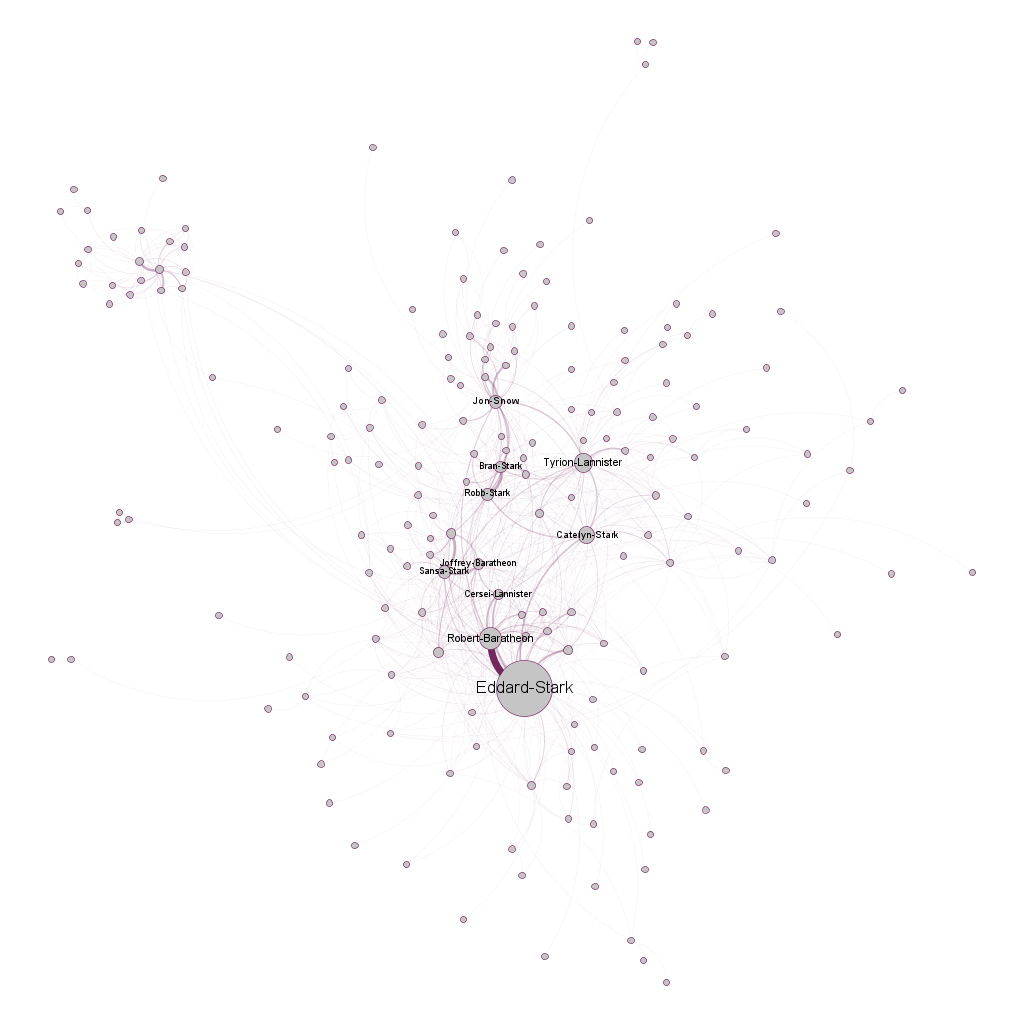

In [2]:
from IPython.display import Image
Image('got_book1_gephi.png')

### 6.5 -- Discussion

Interpret your visualisation. Address the following:

1. Which characters appear as the largest nodes? Does their size reflect their importance in the story?
2. Which edges appear thickest? Do the strongest character pairs correspond to meaningful relationships in Book 1?
3. Does the overall layout reveal any structure -- for example, clusters of characters who are densely connected to each other but loosely connected to the rest of the network?

> **1.** The largest nodes in the visualisation are Eddard Stark and Robert Baratheon, reflecting their high node strength. This aligns closely with their narrative importance, as these characters are central to multiple storylines and interact frequently with many others.

> **2.** The thickest edges are (Eddard Stark) $\Leftrightarrow$ (Robert Baratheon) and (Robb Stark) $\Leftrightarrow$ (Jon Snow) which correspond to the strongest and most meaningful relationships.

> **3.** The network mostly shows one cluster centered around major characters like Eddard Stark. There is only one clearly separate cluster in the top-left corner that stays mostly to itself. Aside from that small group, the layout doesn't show many distinct pockets, as almost everyone is pulled toward the same dense middle.

---

## Part 7 -- Synthesis

Drawing on all parts of this assignment, answer the following questions. Aim for two to four sentences per question.

**7.1** -- Who is the most central character in Book 1? Support your answer with at least two distinct metrics.

> The most central character in Book 1 is Eddard Stark. This is supported by degree (66, the highest in the network) and node strength (1284, also the highest), indicating both many connections and frequent interactions. 

**7.2** -- Does the network exhibit evidence of community structure? What metrics or observations support your conclusion?

> Yes, the network exhibits clear community structure. This is supported by a relatively high average clustering coefficient ( $\approx$ 0.51) and the presence of nodes with local clustering equal to 1, indicating tightly knit groups. The Gephi visualization also reveals clusters connected by bridging characters.

**7.3** -- Based on the full set of metrics computed, would you characterise this as a random or a structured network? Justify your answer.

> This is a structured network, not a random one. Evidence includes the right-skewed (approximately scale-free) degree distribution, high clustering, and disassortative mixing (r < 0). These features indicate hubs, community organization, and non-random interaction patterns.

**7.4** -- What is the most notable finding from your analysis, and what would you investigate further given additional time?

> The most notable finding is the coexistence of high clustering with short path lengths, suggesting a small-world structure. Given more time, it would be valuable to investigate community detection to formally identify factions and compare them with narrative groups in the story.

---

*End of Assignment 01. Submit this notebook and your Gephi image via Moodle.*